# Generador de temperatura y humedad relativa ambiente

Semana 5 - "Modelo base validado".

Usa `generador_ambiente.py` para generar el ciclo diurno de T y HR
ambiente, nominal y perturbado, con la Estación Naranjal (Cenicafé,
Chinchiná, Caldas) como zona climática de referencia.

**Simplificaciones de este v0.1** (ver docstring del módulo para el
detalle): ciclo de temperatura con seno simétrico (no el modelo
asimétrico tipo Parton-Logan), y humedad relativa derivada de un enfoque
psicrométrico simple (presión de vapor real aprox. constante durante el
día).

In [1]:
import sys
sys.path.append(".")

import numpy as np
import matplotlib.pyplot as plt

from generador_ambiente import (
    condiciones_nominales, condiciones_perturbadas, generar_dia,
    T_MIN_MEDIO, T_MAX_MEDIO,
)

## Día nominal

T_min = 16.4 °C, T_max = 26.8 °C (promedios reportados por Cenicafé para
la estación Naranjal).

In [2]:
dia_nominal = generar_dia(condiciones_nominales(), paso_h=0.25)

print(f"T media del dia: {dia_nominal['T'].mean():.2f} C (reportado: 20.8 C)")
print(f"HR media del dia: {dia_nominal['HR'].mean():.1f} % (reportado: 78 %)")
print(f"HR min/max del dia: {dia_nominal['HR'].min():.1f} % / {dia_nominal['HR'].max():.1f} % "
      f"(reportado: ~40-53 % en la tarde / >95 % de noche)")

T media del dia: 21.55 C (reportado: 20.8 C)
HR media del dia: 72.4 % (reportado: 78 %)
HR min/max del dia: 51.3 % / 97.0 % (reportado: ~40-53 % en la tarde / >95 % de noche)


## Días perturbados

Variabilidad día a día (T_min, T_max, presión de vapor) con semilla fija
para reproducibilidad.

In [3]:
rng = np.random.default_rng(42)  # semilla fija, ver guia operativa: "Semillas almacenadas"
dias_perturbados = [generar_dia(condiciones_perturbadas(rng), paso_h=0.25) for _ in range(5)]

## Gráfica: temperatura

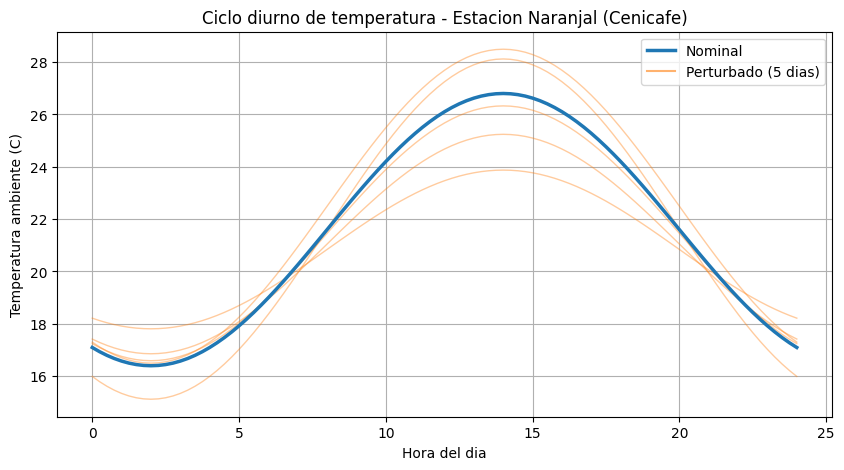

In [4]:
plt.figure(figsize=(10, 5))
for d in dias_perturbados:
    plt.plot(d["hora"], d["T"], color="tab:orange", alpha=0.4, linewidth=1)
plt.plot(dia_nominal["hora"], dia_nominal["T"], color="tab:blue", linewidth=2.5, label="Nominal")
plt.plot([], [], color="tab:orange", alpha=0.6, label="Perturbado (5 dias)")
plt.xlabel("Hora del dia")
plt.ylabel("Temperatura ambiente (C)")
plt.title("Ciclo diurno de temperatura - Estacion Naranjal (Cenicafe)")
plt.legend()
plt.grid(True)
plt.show()

## Gráfica: humedad relativa

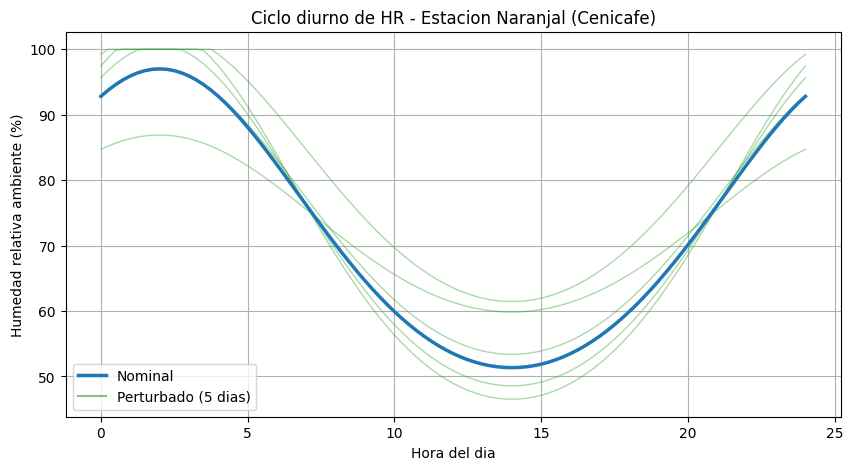

In [5]:
plt.figure(figsize=(10, 5))
for d in dias_perturbados:
    plt.plot(d["hora"], d["HR"], color="tab:green", alpha=0.4, linewidth=1)
plt.plot(dia_nominal["hora"], dia_nominal["HR"], color="tab:blue", linewidth=2.5, label="Nominal")
plt.plot([], [], color="tab:green", alpha=0.6, label="Perturbado (5 dias)")
plt.xlabel("Hora del dia")
plt.ylabel("Humedad relativa ambiente (%)")
plt.title("Ciclo diurno de HR - Estacion Naranjal (Cenicafe)")
plt.legend()
plt.grid(True)
plt.show()

## Próximo paso

Este generador es el insumo de entrada para la línea base activa
(solar + ventilación forzada) y, junto con las ecuaciones de la Tabla 3
de Phitakwinai et al. (2019), para la propuesta supervisada. También es
la base para la campaña Monte Carlo de la semana 8 (múltiples días
perturbados con semillas registradas).